## Enriched Modeling with Process Mining Features

This notebook evaluates whether process mining features improve delay risk prediction.

The enriched dataset combines the original case-level variables with temporal bottleneck features derived from the event log.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

from xgboost import XGBClassifier

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/cases_enriched_process_features.csv")

df.shape, df.head()

((31509, 58),
         case:concept:name                        start_time  \
 0  Application_1000086665  2016-08-03 15:57:21.673000+00:00   
 1  Application_1000158214  2016-06-02 10:14:26.844000+00:00   
 2  Application_1000311556  2016-04-04 15:56:37.675000+00:00   
 3  Application_1000334415  2016-09-15 16:39:17.758000+00:00   
 4  Application_1000339879  2016-03-17 12:57:10.159000+00:00   
 
                            end_time  num_events  num_unique_activities  \
 0  2016-09-05 06:00:36.893000+00:00          22                     13   
 1  2016-06-10 11:02:01.282000+00:00          25                     16   
 2  2016-05-05 06:00:48.963000+00:00          18                     11   
 3  2016-09-29 07:45:34.389000+00:00          40                     18   
 4  2016-03-30 09:11:48.600000+00:00          51                     18   
 
                 loan_goal application_type  requested_amount  duration_days  \
 0  Other, see explanation       New credit            5000.0      3

In [3]:
target = "is_delayed"

excluded_columns = [
    "case:concept:name",
    "start_time",
    "end_time",
    target,
]

numeric_features = [
    column
    for column in df.select_dtypes(include=["number"]).columns
    if column not in excluded_columns
]

numeric_features

['num_events',
 'num_unique_activities',
 'requested_amount',
 'duration_days',
 'activity_a_accepted',
 'activity_a_cancelled',
 'activity_a_complete',
 'activity_a_concept',
 'activity_a_create_application',
 'activity_a_denied',
 'activity_a_incomplete',
 'activity_a_pending',
 'activity_a_submitted',
 'activity_a_validating',
 'activity_o_accepted',
 'activity_o_cancelled',
 'activity_o_create_offer',
 'activity_o_created',
 'activity_o_refused',
 'activity_o_returned',
 'activity_o_sent_(mail_and_online)',
 'activity_o_sent_(online_only)',
 'activity_w_assess_potential_fraud',
 'activity_w_call_after_offers',
 'activity_w_call_incomplete_files',
 'activity_w_complete_application',
 'activity_w_handle_leads',
 'activity_w_personal_loan_collection',
 'activity_w_shortened_completion_',
 'activity_w_validate_application',
 'has_incomplete_files',
 'num_incomplete_file_calls',
 'num_after_offer_calls',
 'num_validation_events',
 'num_offer_events',
 'avg_waiting_time_hours',
 'median_

In [4]:
X = df[numeric_features]
y = df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

In [5]:
xgb_enriched = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42,
)

xgb_enriched.fit(X_train, y_train)

y_pred = xgb_enriched.predict(X_test)
y_proba = xgb_enriched.predict_proba(X_test)[:, 1]

In [6]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

accuracy, roc_auc, pr_auc

(0.9998413202158045, 0.9999980523906904, 0.9999939299670233)

## Initial Enriched Modeling Conclusions

The enriched XGBoost model achieves almost perfect predictive performance after adding process mining features.

The model reaches an accuracy of approximately 0.9998, a ROC AUC close to 1.0000 and a PR AUC close to 1.0000.

This confirms that temporal process mining features are extremely informative for identifying delayed loan applications.

However, these results must be interpreted carefully. The target variable is based on total case duration, while several enriched features are derived from complete-case waiting times and temporal bottlenecks. Therefore, this experiment contains post-outcome information and should be considered a retrospective explanatory model rather than a production-ready early prediction model.

The main value of this experiment is that it validates the strong relationship between operational waiting times and delay risk. It shows that temporal bottlenecks extracted from the event log explain delayed cases far better than static case attributes alone.

For a real deployment scenario, the next step should be to build a leakage-safe model using only information available at a specific prediction point, such as after application submission, after offer creation or after the first customer follow-up.


## Leakage-Safe Early Prediction Model

The previous enriched model used complete-case temporal features, which makes it highly explanatory but not suitable for real-time early prediction.

This section builds an early prediction model using only events available during the first 7 days of each loan application.

The goal is to simulate a realistic operational scenario where the bank wants to identify delay risk before the full process has finished.

In [7]:
events = pd.read_csv("../data/bpi_2017_cleaned.csv")
cases = pd.read_csv("../data/cases_dataset.csv")

events["time:timestamp"] = pd.to_datetime(
    events["time:timestamp"],
    errors="coerce",
)

cases["start_time"] = pd.to_datetime(
    cases["start_time"],
    errors="coerce",
)

events = events.merge(
    cases[["case:concept:name", "start_time", "is_delayed"]],
    on="case:concept:name",
    how="left",
)

events["hours_from_start"] = (
    events["time:timestamp"] - events["start_time"]
).dt.total_seconds() / 3600

early_window_hours = 24 * 7

early_events = events[
    (events["hours_from_start"] >= 0)
    & (events["hours_from_start"] <= early_window_hours)
].copy()

early_events.shape

(671362, 22)

In [8]:
early_events = early_events.sort_values(
    ["case:concept:name", "time:timestamp"]
)

early_events["next_timestamp"] = early_events.groupby(
    "case:concept:name"
)["time:timestamp"].shift(-1)

early_events["waiting_time_hours"] = (
    early_events["next_timestamp"] - early_events["time:timestamp"]
).dt.total_seconds() / 3600

early_temporal_features = early_events.groupby("case:concept:name").agg(
    early_num_events=("concept:name", "count"),
    early_num_unique_activities=("concept:name", "nunique"),
    early_observed_hours=("hours_from_start", "max"),
    early_avg_waiting_time_hours=("waiting_time_hours", "mean"),
    early_median_waiting_time_hours=("waiting_time_hours", "median"),
    early_max_waiting_time_hours=("waiting_time_hours", "max"),
    early_total_waiting_time_hours=("waiting_time_hours", "sum"),
    early_num_waits_over_24h=("waiting_time_hours", lambda values: (values > 24).sum()),
    is_delayed=("is_delayed", "first"),
).reset_index()

early_temporal_features = early_temporal_features.fillna(0)

early_temporal_features.head()

,case:concept:name,early_num_events,early_num_unique_activities,early_observed_hours,early_avg_waiting_time_hours,early_median_waiting_time_hours,early_max_waiting_time_hours,early_total_waiting_time_hours,early_num_waits_over_24h,is_delayed
0,Application_1000086665,19,11,146.469710,8.137206,0.004434,100.366685,146.469710,2,1
1,Application_1000158214,22,14,167.694978,7.985475,0.000345,93.777716,167.694978,2,0
2,Application_1000311556,15,9,94.117407,6.722672,0.000179,93.760812,94.117407,1,0
3,Application_1000334415,37,16,159.592323,4.433120,0.000934,91.055754,159.592323,2,0
4,Application_1000339879,26,14,140.156059,5.606242,0.003424,95.433394,140.156059,2,0


In [9]:
early_activity_counts = pd.crosstab(
    early_events["case:concept:name"],
    early_events["concept:name"],
)

early_activity_counts.columns = [
    "early_activity_"
    + column.lower()
    .replace(" ", "_")
    .replace("(", "")
    .replace(")", "")
    .replace("-", "_")
    for column in early_activity_counts.columns
]

early_activity_counts = early_activity_counts.reset_index()

early_activity_counts.head()

,case:concept:name,early_activity_a_accepted,early_activity_a_cancelled,early_activity_a_complete,early_activity_a_concept,early_activity_a_create_application,early_activity_a_denied,early_activity_a_incomplete,early_activity_a_pending,early_activity_a_submitted,...,early_activity_o_returned,early_activity_o_sent_mail_and_online,early_activity_o_sent_online_only,early_activity_w_assess_potential_fraud,early_activity_w_call_after_offers,early_activity_w_call_incomplete_files,early_activity_w_complete_application,early_activity_w_handle_leads,early_activity_w_shortened_completion_,early_activity_w_validate_application
0,Application_1000086665,1,0,1,1,1,0,0,0,1,...,0,1,0,0,5,0,4,2,0,0
1,Application_1000158214,1,0,1,1,1,0,0,0,1,...,1,1,0,0,4,0,3,2,0,3
2,Application_1000311556,1,0,1,1,1,0,0,0,0,...,0,1,0,0,5,0,3,0,0,0
3,Application_1000334415,1,0,1,1,1,0,1,0,1,...,1,1,0,0,6,6,5,2,0,6
4,Application_1000339879,1,0,1,1,1,0,0,0,1,...,1,1,0,0,6,0,3,2,0,5


In [10]:
early_modeling_df = early_temporal_features.merge(
    early_activity_counts,
    on="case:concept:name",
    how="left",
)

early_modeling_df = early_modeling_df.fillna(0)

early_modeling_df.shape

(31509, 35)

In [11]:
target = "is_delayed"

excluded_columns = [
    "case:concept:name",
    target,
]

early_features = [
    column
    for column in early_modeling_df.select_dtypes(include=["number"]).columns
    if column not in excluded_columns
]

X_early = early_modeling_df[early_features]
y_early = early_modeling_df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_early,
    y_early,
    test_size=0.2,
    random_state=42,
    stratify=y_early,
)

In [12]:
xgb_early = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42,
)

xgb_early.fit(X_train, y_train)

y_pred_early = xgb_early.predict(X_test)
y_proba_early = xgb_early.predict_proba(X_test)[:, 1]

In [13]:
early_accuracy = accuracy_score(y_test, y_pred_early)
early_roc_auc = roc_auc_score(y_test, y_proba_early)
early_pr_auc = average_precision_score(y_test, y_proba_early)

early_accuracy, early_roc_auc, early_pr_auc

(0.75563313233894, 0.7696733053280547, 0.463031328792605)

In [14]:
model_comparison = pd.DataFrame({
    "model": [
        "XGBoost baseline",
        "Retrospective enriched XGBoost",
        "Leakage-safe early XGBoost",
    ],
    "accuracy": [
        0.852586,
        accuracy,
        early_accuracy,
    ],
    "roc_auc": [
        0.903002,
        roc_auc,
        early_roc_auc,
    ],
    "pr_auc": [
        0.730977,
        pr_auc,
        early_pr_auc,
    ],
})

model_comparison

,model,accuracy,roc_auc,pr_auc
0,XGBoost baseline,0.852586,0.903002,0.730977
1,Retrospective enriched XGBoost,0.999841,0.999998,0.999994
2,Leakage-safe early XGBoost,0.755633,0.769673,0.463031


In [15]:
early_feature_importance = pd.Series(
    xgb_early.feature_importances_,
    index=early_features,
).sort_values(ascending=False)

early_feature_importance.head(20)

early_activity_a_validating              0.342078
early_activity_a_submitted               0.156918
early_activity_o_returned                0.147470
early_num_waits_over_24h                 0.037082
early_activity_a_cancelled               0.035413
early_num_unique_activities              0.034296
early_activity_o_created                 0.030674
early_activity_w_handle_leads            0.029513
early_activity_w_call_after_offers       0.028508
early_activity_w_validate_application    0.018458
early_activity_a_accepted                0.013703
early_total_waiting_time_hours           0.013485
early_observed_hours                     0.012828
early_activity_o_refused                 0.008994
early_activity_w_complete_application    0.008680
early_activity_a_denied                  0.008432
early_activity_o_sent_mail_and_online    0.008318
early_activity_o_create_offer            0.007324
early_activity_a_complete                0.006529
early_max_waiting_time_hours             0.006137


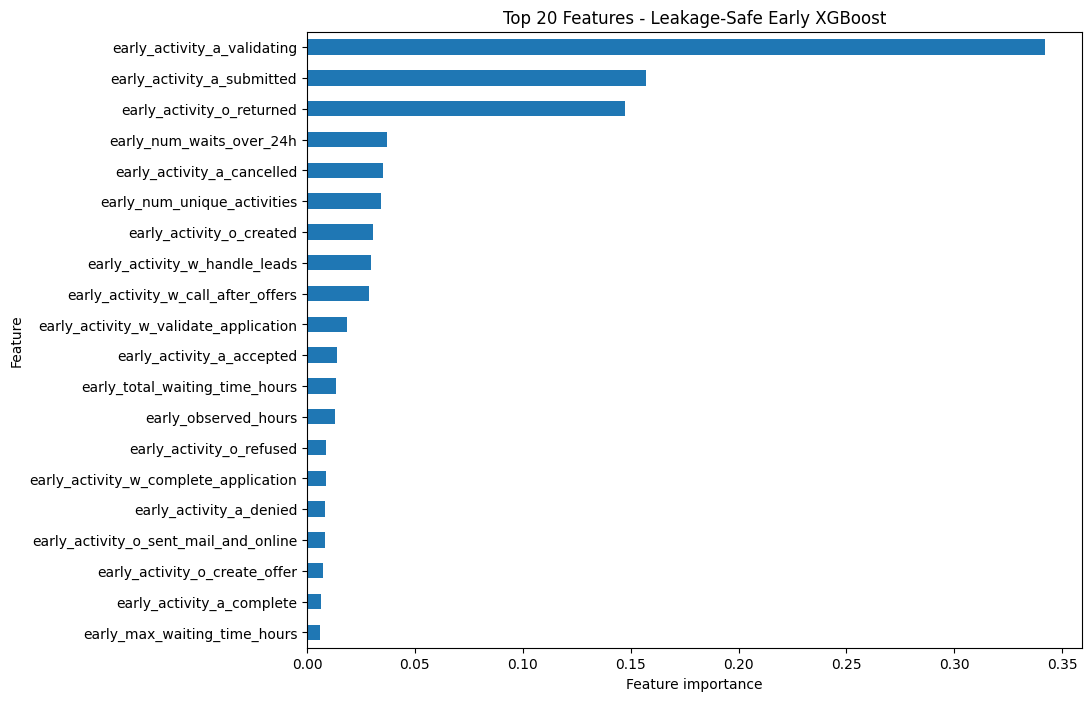

In [16]:
early_feature_importance.head(20).sort_values().plot.barh(
    figsize=(10, 8)
)

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Top 20 Features - Leakage-Safe Early XGBoost")
plt.show()

## Leakage-Safe Early Prediction Conclusions

The leakage-safe early prediction model uses only information available during the first 7 days of each loan application.

This makes the model more realistic for an operational banking scenario, because predictions are made before the full process outcome is known.

The early XGBoost model achieves an accuracy of approximately 0.756, a ROC AUC of 0.770 and a PR AUC of 0.463.

These results are lower than the original baseline and much lower than the retrospective enriched model. However, this is expected because the early model does not use complete-case waiting times or post-outcome information.

The retrospective enriched model shows that full-process temporal bottlenecks almost perfectly explain delayed cases, but it is not suitable for real-time prediction because it uses information from the entire completed process.

In contrast, the leakage-safe model provides a more honest estimate of how well delay risk can be predicted early in the loan application lifecycle.

The most important early predictors are related to validation, submission, returned applications, long waits above 24 hours, cancellations, unique activity count, offer creation, lead handling and after-offer calls.

This suggests that early process behavior already contains useful signals of future delay risk, although the prediction task remains substantially harder when only early information is available.

Overall, this experiment separates retrospective explanation from production-oriented early prediction, making the modeling pipeline more rigorous and realistic.
